In [2]:
%load_ext autoreload
%autoreload 2

In [3]:
import os

# Main libraries
import numpy as np

# Plotting
import matplotlib.pyplot as plt

# We will use Polars for data manipulation
import polars as pl

from config import DATA_PATH
from data import SPECIES_MAPPING

In [46]:
df = pl.read_parquet(
    # os.path.join(DATA_PATH, "tidy", "cpf-level2_growth-periods_with-cc.parquet")
    os.path.join(DATA_PATH, "tidy", "cpf-level2_cleaned.parquet")
).with_columns(species=pl.col("specie").cast(pl.Utf8).replace(SPECIES_MAPPING))

var_df = df.select(
    "plot_id", pl.col("survey_year").alias("year"), "plot_latitude", "plot_longitude", "growth_rate_rel", "species"
)

plot_means

plot_id,growth_rate_mean,lat,lon
str,f64,f64,f64
"""53.0326""",0.000107,52.29,19.36
"""53.0503""",0.000075,51.18,15.25
"""53.0111""",0.000137,54.4,17.59
"""06.0920""",0.000176,56.43,-4.07
"""53.0816""",0.000176,49.2,20.5
…,…,…,…
"""07.0009""",0.000156,53.29,-6.51
"""50.0008""",0.000053,46.35,6.39
"""55.0010""",0.000063,61.0,9.13


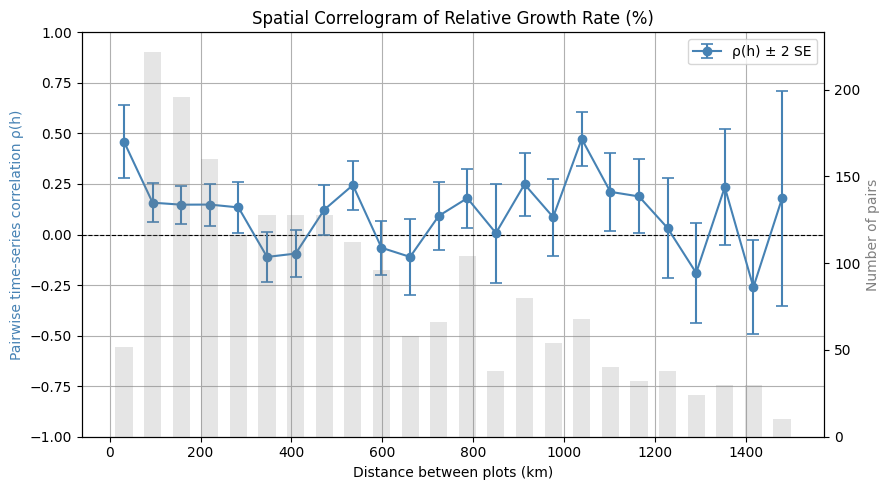

In [66]:
from scipy.stats import pearsonr

# One mean per (plot, year) — preserves temporal structure
plot_year = var_df.group_by(["plot_id", "year"]).agg(
    (pl.mean("growth_rate_rel") * 100).alias("growth_rate_rel_mean"),
    (pl.first("plot_latitude") / 10000).alias("lat"),
    (pl.first("plot_longitude") / 10000).alias("lon"),
)

# Pivot to (plot × year) matrix
growth_wide = plot_year.pivot(
    index="plot_id", on="year", values="growth_rate_rel_mean"
).sort("plot_id")

plot_ids = growth_wide["plot_id"].to_numpy()
Z        = growth_wide.drop("plot_id").to_numpy()  # shape (n_plots, n_years)

# Coordinates per plot (stable after pivot sort)
coords = (
    plot_year.group_by("plot_id")
    .agg(pl.first("lat"), pl.first("lon"))
    .sort("plot_id")
)[["lat", "lon"]].to_numpy()

# Pairwise geodesic distances
dist_matrix = squareform(pdist(coords, metric=lambda u, v: geodesic(u, v).km))

# Pairwise Pearson correlations — only over years where both plots have data
n = len(plot_ids)
corr_matrix = np.full((n, n), np.nan)

for i in range(n):
    for j in range(i + 1, n):
        mask = ~np.isnan(Z[i]) & ~np.isnan(Z[j])
        if mask.sum() >= 3:
            r, _ = pearsonr(Z[i, mask], Z[j, mask])
            corr_matrix[i, j] = corr_matrix[j, i] = r

# Restrict bins to pairs with valid correlations
valid_dist  = np.where(np.isnan(corr_matrix), np.nan, dist_matrix)
bins        = np.linspace(0, np.nanmax(valid_dist), 25)
bin_centers = (bins[:-1] + bins[1:]) / 2

# Per-bin mean, SE, and pair count
corr_mean = np.full(len(bin_centers), np.nan)
corr_se   = np.full(len(bin_centers), np.nan)
n_pairs   = np.zeros(len(bin_centers), dtype=int)

for k, (lo, hi) in enumerate(zip(bins[:-1], bins[1:])):
    mask  = (valid_dist > lo) & (valid_dist <= hi)
    pairs = corr_matrix[mask]
    if len(pairs) >= 2:
        corr_mean[k] = pairs.mean()
        corr_se[k]   = pairs.std() / np.sqrt(len(pairs))
        n_pairs[k]   = len(pairs)

# Plot
fig, ax_corr = plt.subplots(figsize=(9, 5))
ax_pairs = ax_corr.twinx()

valid = ~np.isnan(corr_mean)

ax_corr.errorbar(
    bin_centers[valid], corr_mean[valid],
    yerr=2 * corr_se[valid],
    fmt="o-", color="steelblue",
    capsize=4, capthick=1.2,
    zorder=3, label="ρ(h) ± 2 SE",
)
ax_corr.axhline(0, color="black", linewidth=0.8, linestyle="--")
ax_corr.set_ylim(-1, 1)
ax_corr.set_xlabel("Distance between plots (km)")
ax_corr.set_ylabel("Pairwise time-series correlation ρ(h)", color="steelblue")
ax_corr.set_title("Spatial Correlogram of Relative Growth Rate (%)")
ax_corr.legend(loc="upper right")
ax_corr.grid(True, zorder=0)

ax_pairs.bar(
    bin_centers, n_pairs,
    width=(bins[1] - bins[0]) * 0.6,
    alpha=0.2, color="gray", zorder=2,
)
ax_pairs.set_ylabel("Number of pairs", color="gray")

plt.tight_layout()
plt.show()

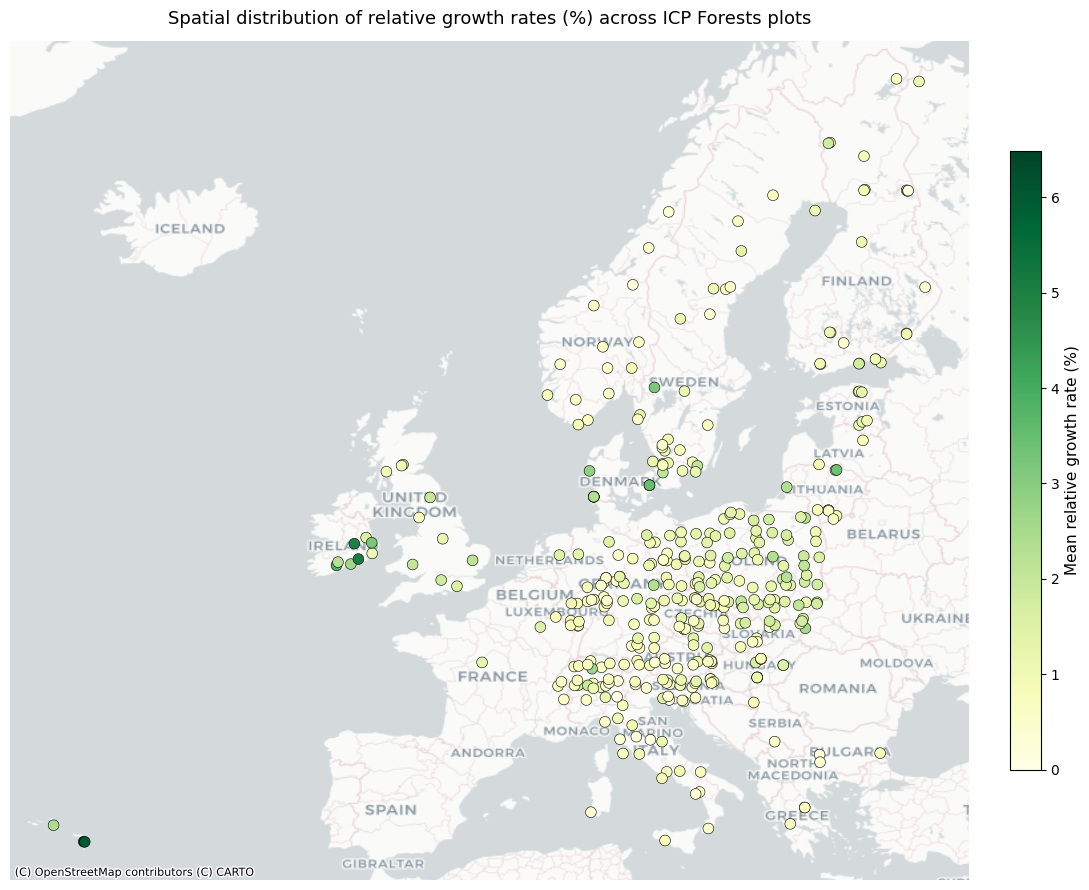

In [67]:
import geopandas as gpd
import contextily as ctx
from shapely.geometry import Point
from matplotlib.colors import TwoSlopeNorm

# Aggregate mean growth rate per plot
plot_data = (
    var_df.group_by("plot_id")
    .agg(
        (pl.mean("growth_rate_rel") * 100).alias("growth_rate_rel_mean"),
        (pl.first("plot_latitude") / 10000).alias("lat"),
        (pl.first("plot_longitude") / 10000).alias("lon"),
    )
)

# Convert to GeoDataFrame — reproject to Web Mercator for contextily
gdf = gpd.GeoDataFrame(
    plot_data.to_pandas(),
    geometry=[Point(xy) for xy in zip(plot_data["lon"], plot_data["lat"])],
    crs="EPSG:4326",
).to_crs(epsg=3857)

# No diverging norm needed — data is strictly positive
fig, ax = plt.subplots(figsize=(11, 9))

sc = ax.scatter(
    gdf.geometry.x,
    gdf.geometry.y,
    c=gdf["growth_rate_rel_mean"],
    cmap="YlGn",
    s=60,
    edgecolor="black",
    linewidth=0.4,
    zorder=3,
)

ctx.add_basemap(
    ax,
    crs=gdf.crs,
    source=ctx.providers.CartoDB.Positron,
    zoom="auto",
    zorder=1,
)

cbar = plt.colorbar(sc, ax=ax, fraction=0.03, pad=0.04)
cbar.set_label("Mean relative growth rate (%)", fontsize=11)

ax.set_axis_off()
ax.set_title("Spatial distribution of relative growth rates (%) across ICP Forests plots", fontsize=13, pad=12)

plt.tight_layout()
plt.show()